In [2]:
# =============================================================================
# 1. IMPORTS AND SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2
import os
import sys
import pathlib
import re
import gc
import yaml
import warnings
import time
from multiprocessing import Pool, cpu_count

# Suppress warnings
warnings.filterwarnings("ignore")

# --- Environment and JAX Configuration ---
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
from jax.lib import xla_bridge
import jax.numpy as jnp
import jax_cosmo.background as bkgrd

# platform = xla_bridge.get_backend().platform
try:
    platform = xla_bridge.get_backend().platform
except:
    from jax.extend import backend
    platform = backend.get_backend().platform
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
print(f"JAX backend: {platform}, Total devices: {jax.device_count()}, Local devices: {jax.local_device_count()}")

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()

# --- Library Imports ---
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import asdf
import healpy as hp
from tqdm import tqdm
import pickle as pk
import h5py as h5

# --- Matplotlib Configuration ---
plt.rcParams['text.usetex'] = True

# --- Add Project-Specific Paths ---
curr_path = pathlib.Path().absolute()
project_base = curr_path.parents[1] 
abs_path_data = project_base / "data"
abs_path_src = project_base / "src"
abs_path_results = project_base / "results"
abs_path_params = project_base / "param_files"

for path in [curr_path, abs_path_data, abs_path_src, abs_path_results, abs_path_params]:
    sys.path.append(str(path))

# --- Import Custom Modules ---
from get_radial_profiles import Profiles
from get_sim_maps import setup_sim_map, get_sim_map
import helpers.constants as constants




JAX backend: gpu, Total devices: 1, Local devices: 1


In [3]:
# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================
def split_array_power_ratio(arr, num_parts, power_val=0.5):
    """Splits an array into parts with sizes proportional to j^power_val."""
    n_total = arr.shape[0]
    j_values = np.arange(1, num_parts + 1)
    weights = j_values**power_val
    sum_of_weights = np.sum(weights)
    ideal_sizes = (n_total / sum_of_weights) * weights
    
    int_sizes = np.floor(ideal_sizes).astype(int)
    remainder = n_total - np.sum(int_sizes)
    
    # Distribute remainder based on fractional parts
    fractional_parts = ideal_sizes - int_sizes
    indices_to_increment = np.argsort(fractional_parts)[-remainder:]
    int_sizes[indices_to_increment] += 1
    
    split_indices = np.cumsum(int_sizes)[:-1]
    return np.split(arr, split_indices)

def read_yaml(file_path):
    """Reads a YAML file and returns its content."""
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def generate_dicts(data):
    """Extracts parameter dictionaries from the main data dictionary."""
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# --- Functions for Parallel Halo Processing ---

def open_data(file, Mmin=1e11, Mmax=1e16):
    df = h5.File(ldir+file, 'r')
    M200c = df['M200c'][()]
    X, Y, Z = df['X'][()], df['Y'][()], df['Z'][()]
    VX, VY, VZ = df['VX'][()], df['VY'][()], df['VZ'][()]
    if (M200c.shape) is not None:
        indsel = np.where((M200c>Mmin) & (M200c<Mmax))[0]
        X_val = X[indsel]
        Y_val = Y[indsel]
        Z_val = Z[indsel]
        M200c_val = M200c[indsel]
        VX_val = VX[indsel]
        VY_val = VY[indsel]
        VZ_val = VZ[indsel]
        Vlos = (VX_val*X_val + VY_val*Y_val + VZ_val*Z_val)/np.sqrt(X_val**2 + Y_val**2 + Z_val**2)
    else:
        X_val = np.array([])
        Y_val = np.array([])
        Z_val = np.array([])
        M200c_val = np.array([])
        VX_val = np.array([])
        VY_val = np.array([])
        VZ_val = np.array([])
        Vlos = np.array([])
    df.close()
    return (X_val, Y_val, Z_val, Vlos, M200c_val)

def concatenate_data(results):
    # Pre-compute lengths for each part
    lengths = np.array([len(result[0]) for result in results])
    total_length = lengths.sum()

    # Pre-allocate arrays
    X_all = np.empty(total_length)
    Y_all = np.empty(total_length)
    Z_all = np.empty(total_length)
    Vlos_all = np.empty(total_length)
    M200_all = np.empty(total_length)

    # Calculate start and end indices
    end_ind_all = np.cumsum(lengths)
    start_ind_all = np.roll(end_ind_all, 1)
    start_ind_all[0] = 0


    # Use array slicing for assignment
    for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
        X_all[start:end] = result[0]
        Y_all[start:end] = result[1]
        Z_all[start:end] = result[2]
        Vlos_all[start:end] = result[3]
        M200_all[start:end] = result[4]

    return X_all, Y_all, Z_all, Vlos_all, M200_all

def process_halo(args):
    """Finds pixels near a single halo."""
    jhalo, ra_all_np, dec_all_np, halo_cat_R200c_np, halo_cat_DV_np, max_paint_R200c_factor, nside_local, pixel_dtype = args
    
    vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)
    # Angle subtended by the painting radius
    nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
    nearby_pix = hp.query_disc(nside_local, vec, nearby_angle)
    
    if len(nearby_pix) == 0:
        return None
    
    nearby_pix = np.asarray(nearby_pix, dtype=pixel_dtype)
    nearby_ra, nearby_dec = hp.pix2ang(nside_local, nearby_pix, lonlat=True)
    
    # Haversine formula to calculate angular separation
    ra1, dec1 = np.radians(ra_all_np[jhalo]), np.radians(dec_all_np[jhalo])
    ra2, dec2 = np.radians(nearby_ra), np.radians(nearby_dec)
    
    a = np.sin((dec1 - dec2)/2)**2 + np.cos(dec1) * np.cos(dec2) * np.sin((ra1 - ra2)/2)**2
    theta = np.clip(2 * np.arcsin(np.sqrt(a)), 1e-10, np.pi)  # Angular separation in radians
    
    # Projected distance in Mpc
    distances = (halo_cat_DV_np[jhalo] * theta).astype(np.float32)
    
    return (nearby_pix, distances, jhalo, len(nearby_pix))

def concatenate_batch_results(results, M_all_chunk, z_all_chunk, vlos_all_chunk, halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype):
    """Concatenates results from a single batch of parallel processing."""
    if not results:
        return None
        
    lengths = np.array([res[3] for res in results], dtype=np.int32)
    total_length = lengths.sum()
    
    # Pre-allocate arrays for efficiency
    nearby_pix_all = np.empty(total_length, dtype=pixel_dtype)
    distances_pix_all = np.empty(total_length, dtype=np.float32)
    halo_indices = np.empty(total_length, dtype=np.int32)
    
    end_indices = np.cumsum(lengths)
    start_indices = np.concatenate([[0], end_indices[:-1]])
    
    for i, (start, end, res) in enumerate(zip(start_indices, end_indices, results)):
        nearby_pix_all[start:end] = res[0]
        distances_pix_all[start:end] = res[1]
        halo_indices[start:end] = res[2]
    
    original_halo_indices = np.array([res[2] for res in results], dtype=np.int32)
    
    # Map pixel-level properties back from halo-level properties
    logM_ind_all = np.log(M_all_chunk[halo_indices]).astype(np.float32)
    z_ind_all = z_all_chunk[halo_indices].astype(np.float32)
    vlos_ind_all = vlos_all_chunk[halo_indices].astype(np.float32)
    
    # Map halo-level properties
    ang_distance_all = halo_cat_DV_np[original_halo_indices].astype(np.float32)
    rp_max_all = (max_paint_R200c_factor * halo_cat_R200c_np[original_halo_indices]).astype(np.float32)
    
    return (nearby_pix_all, distances_pix_all, start_indices, end_indices, 
            logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all)

def final_concatenate_batches(all_results, pixel_dtype):
    """Final concatenation of results from all batches."""
    total_pix = sum(len(res[0]) for res in all_results)
    total_halos = sum(len(res[2]) for res in all_results)
    
    # Pre-allocate final arrays
    final_nearby_pix = np.empty(total_pix, dtype=pixel_dtype)
    final_distances = np.empty(total_pix, dtype=np.float32)
    final_logM = np.empty(total_pix, dtype=np.float32)
    final_z = np.empty(total_pix, dtype=np.float32)
    final_vlos = np.empty(total_pix, dtype=np.float32)
    final_start_ind = np.empty(total_halos, dtype=np.int32)
    final_end_ind = np.empty(total_halos, dtype=np.int32)
    final_ang_dist = np.empty(total_halos, dtype=np.float32)
    final_rp_max = np.empty(total_halos, dtype=np.float32)
    
    pix_offset, halo_offset = 0, 0
    for result in all_results:
        n_pix_batch = len(result[0])
        n_halo_batch = len(result[2])
        
        # Unpack batch results
        nearby_pix_b, dist_b, start_b, end_b, logM_b, z_b, vlos_b, ang_dist_b, rp_max_b = result
        
        # Fill pixel-level arrays
        final_nearby_pix[pix_offset : pix_offset + n_pix_batch] = nearby_pix_b
        final_distances[pix_offset : pix_offset + n_pix_batch] = dist_b
        final_logM[pix_offset : pix_offset + n_pix_batch] = logM_b
        final_z[pix_offset : pix_offset + n_pix_batch] = z_b
        final_vlos[pix_offset : pix_offset + n_pix_batch] = vlos_b
        
        # Fill halo-level arrays, adjusting indices with the offset
        final_start_ind[halo_offset : halo_offset + n_halo_batch] = start_b + pix_offset
        final_end_ind[halo_offset : halo_offset + n_halo_batch] = end_b + pix_offset
        final_ang_dist[halo_offset : halo_offset + n_halo_batch] = ang_dist_b
        final_rp_max[halo_offset : halo_offset + n_halo_batch] = rp_max_b
        
        pix_offset += n_pix_batch
        halo_offset += n_halo_batch
        
    return (final_nearby_pix, final_distances, final_start_ind, final_end_ind,
            final_logM, final_z, final_vlos, final_ang_dist, final_rp_max)

def process_halos_in_batches(M_all_chunk, ra_all_chunk, dec_all_chunk, z_all_chunk, vlos_all_chunk, 
                             halo_cat_R200c, halo_cat_DA, max_paint_R200c_factor, nside, batch_size=1000):
    """Manages the parallel processing of halos in manageable batches."""
    pixel_dtype = np.int32 if nside <= 8192 else np.int64
    
    ra_all_np = np.clip(np.array(ra_all_chunk, dtype=np.float32), 0.01, 359.99)
    dec_all_np = np.clip(np.array(dec_all_chunk, dtype=np.float32), -89.99, 89.99)
    halo_cat_R200c_np = np.array(halo_cat_R200c, dtype=np.float32)
    halo_cat_DV_np = np.array(halo_cat_DA, dtype=np.float32)
    
    n_halos = len(z_all_chunk)
    all_results = []
    
    with Pool(cpu_count()) as pool:
        for batch_start in range(0, n_halos, batch_size):
            batch_end = min(batch_start + batch_size, n_halos)
            print(f"Processing halo batch {batch_start//batch_size + 1}/{(n_halos - 1)//batch_size + 1}...")
            
            # Create arguments for each halo in the batch
            batch_args = [(jhalo, ra_all_np, dec_all_np, halo_cat_R200c_np, halo_cat_DV_np, 
                           max_paint_R200c_factor, nside, pixel_dtype) for jhalo in range(batch_start, batch_end)]
            
            # Map processing to the pool
            batch_results = pool.map(process_halo, batch_args)
            batch_results = [r for r in batch_results if r is not None]
            
            if batch_results:
                # Concatenate results from the current batch
                batch_data = concatenate_batch_results(batch_results, M_all_chunk, z_all_chunk, vlos_all_chunk, 
                                                       halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype)
                if batch_data is not None:
                    all_results.append(batch_data)
            
            del batch_results, batch_args
            gc.collect()
    
    if not all_results:
        return None
        
    return final_concatenate_batches(all_results, pixel_dtype)




In [4]:
# --- Timing Flag ---
PROFILE_TIMING = True
# PROFILE_TIMING = False

if PROFILE_TIMING:
    script_start_time = time.perf_counter()
    
# --- Analysis Parameters ---
# nside = 1024
nside = 512
jdevice = 0
Ndevices = 1

# --- Load Configuration and Initialize Models ---
if PROFILE_TIMING:
    setup_start_time = time.perf_counter()

yaml_file_path = f'{str(abs_path_params)}/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

# Override halo parameters for this analysis
halo_params_dict.update({
    'rmin': 0.00075, 'rmax': 10.0, 'nr': 32,
    'zmin': 0.005, 'zmax': 2.0, 'nz':31,
    'lg10_Mmin': 10.75, 'lg10_Mmax': 16.0, 'nM': 47
})

# cosmology of the backlight simulations
cosmo_params_dict = {'w0': -1.0, 'flat': True, 'H0': 67.11, 'Om0': 0.3175, 
                        'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624}

# Get the radial profiles
Prof_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)

# Setup simulated map generation. This also pre-computes some necessary 2D projection of the profiles needed for pasting
mock_params_dict_setup = {}
mock_params_dict_setup['nside'] = nside
mock_params_dict_setup['get_ymap'] = True
mock_params_dict_setup['get_kSZmap'] = True
mock_params_dict_setup['get_taumap'] = True
mock_params_dict_setup['get_kappamap'] = True
mock_params_dict_setup['get_baryonifiedmap'] = True
mock_params_dict_setup['get_galmap'] = True
mock_params_dict_setup['smooth_profiles'] = True
Paste_test = setup_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict_setup, Profiles_obj=Prof_test)

chi2z_interp = interpolate.interp1d(np.log(Prof_test.chi_array), Prof_test.z_array, fill_value="extrapolate")

if PROFILE_TIMING:
    setup_end_time = time.perf_counter()
    print(f"\n[PROFILE] Initial setup time: {setup_end_time - setup_start_time:.2f} seconds")

# --- Identify Redshift Slices to Process ---
sim_file_path = '/work/hdd/bdne/spandey3/backlight/fiducial/100'
data_dir = f'{sim_file_path}/halos'
files = [f for f in os.listdir(data_dir)]
zlist = np.array(sorted(np.array([int(item) for item in files], dtype=int)))

z2chi_file = f'{sim_file_path}/z2chi_interp.txt'
z2chi = np.loadtxt(z2chi_file)

zlist_file = f'{sim_file_path}/zlist.txt'
zlist = np.loadtxt(zlist_file)
snap_num_all = zlist[:,0].astype(int)
zval_all = zlist[:,1]





[PROFILE] Initial setup time: 71.73 seconds


In [6]:
indz = np.where(zval_all < 0.2)[0][0]
zcen = zval_all[indz]
min_z = zcen + (zval_all[indz] - zval_all[indz-1])/2
max_z = zcen - (zval_all[indz+1] - zval_all[indz])/2

snap_num = snap_num_all[indz]
ldir = f'{sim_file_path}/halos/{snap_num}/'
files_all = os.listdir(ldir)
with Pool(cpu_count()) as pool:
    results = pool.map(open_data, files_all)
X_all, Y_all, Z_all, vlos_all, M200c_all = concatenate_data(results)
ra_all, dec_all = hp.vec2ang(np.array([X_all, Y_all, Z_all]).T, lonlat=True)
z_all = zcen * np.ones_like(ra_all)
ra_all, dec_all = np.clip(ra_all, 0, 360), np.clip(dec_all, -90, 90)

print(zcen, len(ra_all), np.min(np.log10(M200c_all)), np.max(np.log10(M200c_all)))




0.1959877 3441246 11.011062706651876 15.131682798943451


In [7]:
rho_m = Prof_test.get_rho_m(0.0)
Mtot = rho_m * (1000)**3
part_mass = float(Mtot/2048**3)

map_unbound = hp.read_map(f'{sim_file_path}/compressed_massMaps/massSheet_unbound_z_{int(snap_num)}.fits.gz')
map_unbound_ds = hp.ud_grade(np.array(map_unbound*part_mass), nside, power=-2)

map_tot_orig = hp.read_map(f'{sim_file_path}/compressed_massMaps/massSheet_tot_z_{int(snap_num)}.fits.gz')
map_tot_orig_ds = hp.ud_grade(np.array(map_tot_orig*part_mass), nside, power=-2)

map_bound = map_tot_orig - map_unbound
map_bound_ds = hp.ud_grade(np.array(map_bound*part_mass), nside, power=-2)

# map_unbound_ds_smooth = hp.smoothing(map_unbound_ds, sigma=mock_map.sigma_val)
# map_bound_ds_smooth = hp.smoothing(map_bound_ds, sigma=mock_map.sigma_val)



In [8]:
# --- Chunking and Map Generation ---
nh_max_map = {8192: 4e3, 4096: 5e4, 2048: 5e5, 1024: 1e7, 512: 1e7}
nh_max = nh_max_map.get(nside, 1e5) # Default if nside not in map
nsel = len(M200c_all)
num_chunks = int(np.ceil(nsel / nh_max)) if nsel > nh_max else 1

map_rhom, map_rhom_dmo, map_kappa, map_ymap, map_ksz, map_tau = (np.zeros(12 * nside**2, dtype=np.float32) for _ in range(6))
mock_gals_all = {}

for i in tqdm(range(num_chunks), desc=f"Painting maps for z={zcen:.3f}"):
    start, end = int(i * nh_max), int((i + 1) * nh_max)
    M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk = (
        M200c_all[start:end], ra_all[start:end], dec_all[start:end],
        z_all[start:end], vlos_all[start:end]
    )
    
    scale_fac = 1. / (1. + z_chunk)
    rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(Prof_test.cosmo_jax, scale_fac) * 1e9
    rho_treshold = 200 * rho_c_z
    R200c = (M_chunk * 3.0 / (4.0 * jnp.pi * rho_treshold))**(1.0 / 3.0)
    DA = bkgrd.angular_diameter_distance(Prof_test.cosmo_jax, scale_fac)
    
    if PROFILE_TIMING:
        pixel_finding_start_time = time.perf_counter()
    
    max_paint_R200c_factor = 3.0
    batch_size = int(nh_max // 2) if nh_max > 2 else 1
    result = process_halos_in_batches(
        M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk,
        R200c, DA, max_paint_R200c_factor, nside, batch_size
    )
    
    if PROFILE_TIMING:
        pixel_finding_end_time = time.perf_counter()
        print(f"\n[PROFILE] Chunk {i+1}/{num_chunks} - Pixel finding: {pixel_finding_end_time - pixel_finding_start_time:.2f} seconds")
    
    if result:
        mock_params_dict = {
            **mock_params_dict_setup,
            'halo_z': jnp.array(z_chunk, dtype=jnp.float32),
            'halo_ra': jnp.array(ra_chunk, dtype=jnp.float32),
            'halo_dec': jnp.array(dec_chunk, dtype=jnp.float32),
            'halo_M': jnp.array(M_chunk, dtype=jnp.float32),
            'halo_vlos': jnp.array(vlos_chunk, dtype=jnp.float32),
            'nearby_pix_all': jnp.array(result[0]),
            'start_ind': jnp.array(result[2], dtype=jnp.int32),
            'end_ind': jnp.array(result[3], dtype=jnp.int32),
            'pix_prop_all': (jnp.array([np.log(result[1]), result[5], result[4], result[6]]).T).astype(jnp.float32),
            'ang_distance_all': jnp.array(result[7]),
            'rp_max_all': jnp.array(result[8]),
            'profile_timing': PROFILE_TIMING
        }
        
        if PROFILE_TIMING:
            map_gen_start_time = time.perf_counter()
        
        mock_map = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=Paste_test)
        
        map_rhom += np.nan_to_num(mock_map.rhommap_final)
        map_rhom_dmo += np.nan_to_num(mock_map.rhom_dmo_map_final)
        map_ymap += np.nan_to_num(mock_map.ymap_final)
        map_ksz += np.nan_to_num(mock_map.kszmap_final)
        map_tau += np.nan_to_num(mock_map.taumap_final)
        mock_gals_all[i] = mock_map.final_galaxy_catalog

        map_tot_orig_ds_smooth = hp.smoothing(map_tot_orig_ds, sigma=mock_map.sigma_val)

        map_diff = map_rhom - map_rhom_dmo
        map_kappa += map_tot_orig_ds_smooth + map_diff

        if PROFILE_TIMING:
            map_gen_end_time = time.perf_counter()
            print(f"[PROFILE] Chunk {i+1}/{num_chunks} - JAX map generation: {map_gen_end_time - map_gen_start_time:.2f} seconds")
        
        # del mock_map, mock_params_dict, result
        # jax.clear_caches()
        # gc.collect()




Painting maps for z=0.196:   0%|          | 0/1 [00:00<?, ?it/s]

Processing halo batch 1/1...

[PROFILE] Chunk 1/1 - Pixel finding: 50.71 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 0.7691 seconds
setup_tau_interpolator             : 0.3247 seconds
ymap_generation_and_assembly       : 1.9003 seconds
ksz_map_generation_and_assembly    : 1.3241 seconds
tau_map_generation_and_assembly    : 1.1916 seconds
kappa_map_generation_and_assembly  : 1.2656 seconds
kappa_dmo_map_generation_and_assembly: 1.2390 seconds
galaxy_ppf_interpolator_creation   : 0.1713 seconds
galaxy_population                  : 3.7189 seconds
galaxy_catalog_filtering           : 0.3701 seconds
total_execution                    : 12.2899 seconds
---------------------------------------



Painting maps for z=0.196: 100%|██████████| 1/1 [01:05<00:00, 65.35s/it]

[PROFILE] Chunk 1/1 - JAX map generation: 13.03 seconds


In [9]:
gal_ra_all = mock_gals_all[0][:,0]
gal_dec_all = mock_gals_all[0][:,1]
map_gal = np.zeros(12 * nside**2, dtype=np.float32)
pix_gal = hp.ang2pix(nside, gal_ra_all, gal_dec_all, lonlat=True)
np.add.at(map_gal, pix_gal, 1.)
delta_gal = (map_gal)/np.mean(map_gal)
delta_gal = hp.smoothing(delta_gal, sigma=mock_map.sigma_val)


In [13]:
Cl_gy = hp.anafast(delta_gal, map_ymap, lmax=3*nside-1)
Cl_gk = hp.anafast(delta_gal, map_kappa/np.mean(map_kappa), lmax=3*nside-1)
Cl_gtau = hp.anafast(delta_gal, map_tau, lmax=3*nside-1)
Cl_gksz2 = hp.anafast(delta_gal, map_ksz**2, lmax=3*nside-1)
ell = np.arange(len(Cl_gy))




Text(0, 0.5, '$\\ell(\\ell+1)C_\\ell/2\\pi$')

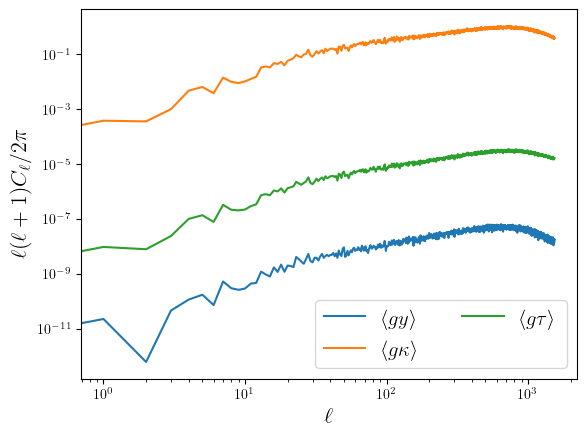

In [22]:
plt.figure()
plt.plot(ell, ell*(ell+1)*Cl_gy/(2.*np.pi), label=r'$\langle g y \rangle$')
plt.plot(ell, ell*(ell+1)*Cl_gk/(2.*np.pi), label=r'$\langle g \kappa \rangle$')
plt.plot(ell, ell*(ell+1)*Cl_gtau/(2.*np.pi), label=r'$\langle g \tau \rangle$')
# plt.plot(ell, ell*(ell+1)*Cl_gksz2/(2.*np.pi), label=r'$\langle g \textrm{kSZ}^2 \rangle$')

plt.legend(ncol=2, fontsize=15, loc='lower right')
# plt.ylim()
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$\ell(\ell+1)C_\ell/2\pi$', fontsize=16)


